# Exploración y decisión de arquitectura — clasificación RX

**Proyecto:** laSalle Health Center · **Clases:** `sana` · `neumonia` · `covid`

1. **Día 4:** comparación **CNN propia** vs **Transfer Learning** (ResNet50, EfficientNetB0, DenseNet121).
2. **Día 5 (este informe):** validación empírica del modelo elegido (`rx_resnet50_v1`) y recomendación final.

Documentación relacionada: `docs/ml/arquitectura-rx.md`, `docs/ml/resultados-entrenamiento-v1.md`.

> **Kernel:** selecciona `Python 3.12 (salle-ml)` — entorno `ml/.venv-metal` (TensorFlow + ipykernel). Si falta: `cd ml && source .venv-metal/bin/activate && pip install -r requirements.txt && python -m ipykernel install --user --name=salle-ml --display-name="Python 3.12 (salle-ml)"`.

In [27]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models.architectures import (
    LABELS,
    build_baseline_cnn,
    build_transfer_classifier,
    compare_architectures,
)

FEATURES_DIR = ROOT.parent / "data" / "processed" / "features" / "v1"
TRAIN_DIR = FEATURES_DIR / "train"
print("Features:", FEATURES_DIR)
print("Existe:", FEATURES_DIR.exists())

Features: /Users/yagoalonso/Documents/MASTER/practica-tocha/data/processed/features/v1
Existe: True


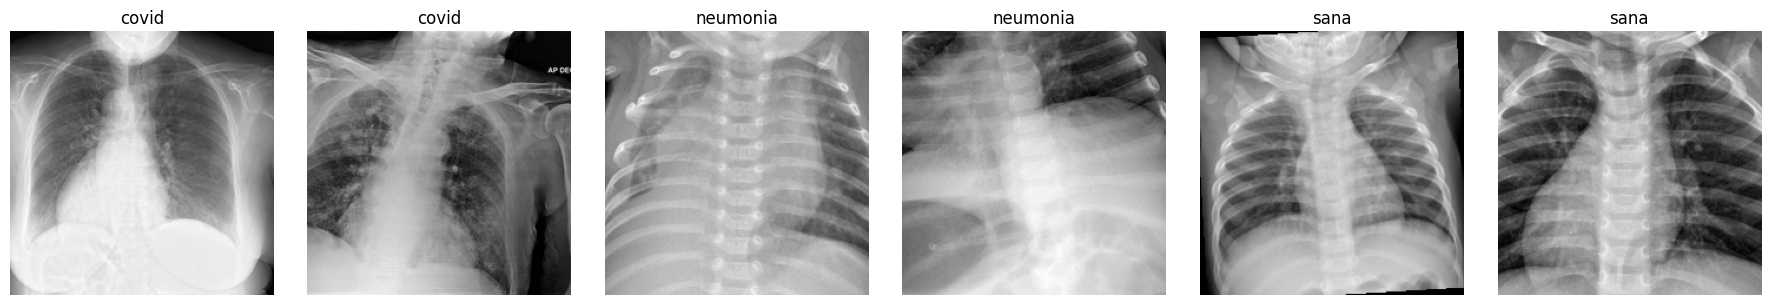

In [28]:
def sample_paths(n_per_label: int = 2) -> list[Path]:
    paths = []
    for label in LABELS:
        folder = TRAIN_DIR / label
        if not folder.is_dir():
            continue
        for p in sorted(folder.glob("*.jpg"))[:n_per_label]:
            paths.append(p)
    return paths

samples = sample_paths()
if not samples:
    raise FileNotFoundError(
        "No hay imágenes en features/v1/train. Ejecuta preprocess_images (Día 3)."
    )

fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3))
if len(samples) == 1:
    axes = [axes]
for ax, path in zip(axes, samples):
    ax.imshow(Image.open(path))
    ax.set_title(path.parent.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [29]:
comparison = pd.DataFrame(compare_architectures())
comparison

,architecture,trainable,non_trainable,total
0,baseline_cnn,93635,0,93635
1,resnet50,6147,23587712,23593859
2,efficientnetb0,3843,4049571,4053414
3,densenet121,3075,7037504,7040579


In [30]:
baseline = build_baseline_cnn()
resnet = build_transfer_classifier("resnet50", trainable_backbone=False)

print("=== Baseline CNN ===")
baseline.summary()
print("\n=== ResNet50 (modelo elegido) ===")
resnet.summary()

=== Baseline CNN ===


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rx_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,635 (365.76 KB)

 Trainable params: 93,635 (365.76 KB)

...

Model: "resnet50_rx_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rx_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
import numpy as np

batch = np.stack(
    [np.array(Image.open(p).resize((224, 224))) for p in samples[:3]],
    axis=0,
)
probs = resnet.predict(batch, verbose=0)
for path, prob in zip(samples[:3], probs):
    pred = LABELS[int(np.argmax(prob))]
    print(f"{path.name} ({path.parent.name}) -> {pred} (pesos aleatorios, sin entrenar)")

0001025bbbb2609a_flip.jpg (covid) -> sana (pesos aleatorios, sin entrenar)
001fa2c009eba2fc_original.jpg (covid) -> sana (pesos aleatorios, sin entrenar)
00007996e91c2e12_flip.jpg (neumonia) -> sana (pesos aleatorios, sin entrenar)


## Conclusión exploratoria (Día 4)

El [`enunciado.md`](../../enunciado.md) pide **investigar** arquitecturas (CNN, modelos preentrenados, etc.) para clasificar RX en **sana · neumonia · covid**.

- **Hipótesis inicial:** Transfer Learning con **ResNet50**.
- **Alternativas a entrenar y comparar:** baseline CNN, EfficientNetB0, DenseNet121.
- La **decisión justificada** (métricas + criterio clínico del encargo) está en el informe Día 5.

---
## Informe de decisión de modelo — alineado con el encargo

Referencia: [`enunciado.md`](../../enunciado.md) · sección *Aprendizaje Automático y Redes Neuronales: Clasificación de Radiografías*.

### Qué exige el encargo

| Requisito del enunciado | Cómo lo cubrimos en este informe |
|-------------------------|----------------------------------|
| Módulo de **Deep Learning** sobre imágenes médicas | Clasificador de RX 224×224 en TensorFlow/Keras |
| Clasificación **triple**: sana · neumonía · COVID-19 | Tres clases en `features/v1/` |
| **Investigar** y elegir arquitectura (CNN, preentrenados, etc.) | Comparativa de 4 candidatos entrenados con el mismo protocolo |
| Tratamiento de datos (resize, normalización, augmentation) | Pipeline Spark Día 3 + `Rescaling(1/255)` |
| Integración con infraestructura | Features en MinIO/PostgreSQL → servicio `ml` Docker |
| La nota **no** depende del accuracy perfecto | Priorizamos matriz de confusión, FN/FP y reflexión clínica |
| Matriz de confusión y errores COVID ↔ neumonía | Por modelo + `docs/ml/evaluacion-clinica-v1.md` |
| Justificación técnica y limitaciones | Tabla comparativa + decisión final |

### Flujo en el notebook

1. **Configuración** (rutas locales + funciones).
2. Por cada candidato: **Entrenar** → **Estadísticas** (métricas test, matriz, curvas).
3. **Comparativa y elección** según criterios del encargo (rendimiento + impacto clínico + operativa).

> Cada entrenamiento ~1–2 h en GPU. `SKIP_IF_EXISTS = True` reutiliza informes existentes (p. ej. ResNet50 ya entrenado).



In [32]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

# Forzar ruta local (evita /opt/data de Docker en el kernel)
FEATURES_LOCAL = (ROOT.parent / "data" / "processed" / "features").resolve()
os.environ["FEATURES_ROOT"] = str(FEATURES_LOCAL)
os.environ["FEATURES_VERSION"] = "v1"

import importlib
import training_core
importlib.reload(training_core)
from models.architectures import build_baseline_cnn, build_transfer_classifier
from training_core import (
    ModelSpec,
    fn_neumonia_sana,
    get_data_dir,
    load_report,
    refresh_paths,
    report_to_comparison_entry,
    run_training,
    write_architecture_comparison,
)

os.environ.setdefault("TRAIN_BATCH_SIZE", "16")
os.environ.setdefault("HEAD_EPOCHS", os.environ.get("COMPARE_HEAD_EPOCHS", "8"))
os.environ.setdefault("FINETUNE_EPOCHS", os.environ.get("COMPARE_FINETUNE_EPOCHS", "6"))
os.environ.setdefault("EXPORT_SAVEDMODEL", "0")

SKIP_IF_EXISTS = True  # False = reentrenar aunque exista informe
REPORTS = ROOT / "models" / "reports"
ARCH_ORDER = ["baseline_cnn", "resnet50", "efficientnetb0", "densenet121"]

SPECS = {
    "baseline_cnn": ModelSpec(
        arch_id="baseline_cnn",
        model_version="rx_baseline_cnn_v1",
        build_model=build_baseline_cnn,
        finetune=False,
    ),
    "resnet50": ModelSpec(
        arch_id="resnet50",
        model_version="rx_resnet50_v1",
        build_model=lambda: build_transfer_classifier("resnet50", trainable_backbone=False),
        finetune=True,
        finetune_layers=40,
        legacy_reports=True,
    ),
    "efficientnetb0": ModelSpec(
        arch_id="efficientnetb0",
        model_version="rx_efficientnetb0_v1",
        build_model=lambda: build_transfer_classifier("efficientnetb0", trainable_backbone=False),
        finetune=True,
        finetune_layers=30,
    ),
    "densenet121": ModelSpec(
        arch_id="densenet121",
        model_version="rx_densenet121_v1",
        build_model=lambda: build_transfer_classifier("densenet121", trainable_backbone=False),
        finetune=True,
        finetune_layers=40,
    ),
}

reports: dict[str, dict] = {}


def train_arch(arch_id: str) -> dict:
    refresh_paths()
    spec = SPECS[arch_id]
    if SKIP_IF_EXISTS and spec.report_json.is_file():
        print(f"[{arch_id}] Reutilizando {spec.report_json.name}")
        report = load_report(spec)
    else:
        report = run_training(spec)
    report.setdefault("arch_id", arch_id)
    reports[arch_id] = report
    return report


def show_arch_stats(arch_id: str) -> None:
    if arch_id not in reports:
        spec = SPECS[arch_id]
        if spec.report_json.is_file():
            reports[arch_id] = load_report(spec)
        else:
            raise KeyError(f"Entrena primero {arch_id} (celda Entrenar)")
    report = reports[arch_id]
    spec = SPECS[arch_id]
    test = report["metrics_by_split"]["test"]
    cm = np.array(test["confusion_matrix"])
    fn = report.get("fn_neumonia_sana", fn_neumonia_sana(cm))
    hp = report.get("hyperparameters", {})

    print(f"## {arch_id} — {report['model_version']}")
    if hp.get("total_params"):
        print(f"Parámetros: {hp['total_params']:,}")
    print(f"TEST accuracy: {test['accuracy']:.1%} | F1 macro: {test['f1_macro']:.1%} | FN neumonía→sana: {fn}")

    rows = []
    for split in ("train", "validation", "test"):
        m = report["metrics_by_split"][split]
        rows.append({"split": split, "n": m["n_samples"], "acc": m["accuracy"], "f1": m["f1_macro"]})
    df = pd.DataFrame(rows)
    display(df.assign(acc=df["acc"].map(lambda x: f"{x:.1%}"), f1=df["f1"].map(lambda x: f"{x:.1%}")))

    per = pd.DataFrame(test["per_class"]).T[["precision", "recall", "f1", "support"]]
    for c in ("precision", "recall", "f1"):
        per[c] = per[c].map(lambda x: f"{x:.1%}")
    display(per)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3), test["labels"])
    ax.set_yticks(range(3), test["labels"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz test — {arch_id}")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    log1 = spec.report_dir / "training_log_phase1.csv"
    if log1.is_file():
        df1 = pd.read_csv(log1)
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(df1["val_accuracy"], marker="o", label="val_accuracy")
        log2 = spec.report_dir / "training_log_phase2.csv"
        if log2.is_file():
            df2 = pd.read_csv(log2)
            off = len(df1)
            ax.plot(range(off, off + len(df2)), df2["val_accuracy"], marker="o")
            ax.axvline(off - 0.5, ls="--", color="gray")
        ax.set_title(f"Curvas validación — {arch_id}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

refresh_paths()
dd = get_data_dir()
print("Dataset:", dd, "| existe:", (dd / "train").is_dir())
if SPECS["resnet50"].report_json.is_file():
    reports["resnet50"] = load_report(SPECS["resnet50"])
    print("ResNet50 cargado desde informe existente.")
print("Configuración lista.")


Dataset: /Users/yagoalonso/Documents/MASTER/practica-tocha/data/processed/features/v1 | existe: True
ResNet50 cargado desde informe existente.
Configuración lista.


### 1. Baseline CNN (investigación — CNN desde cero)

*Opción del enunciado:* red convolucional propia, sin preentrenamiento. Sirve de **referencia** frente a transfer learning.



In [33]:
train_arch("baseline_cnn")


[baseline_cnn] Reutilizando training_report.json


{'arch_id': 'baseline_cnn',
 'model_version': 'rx_baseline_cnn_v1',
 'features_dir': '/Users/yagoalonso/Documents/MASTER/practica-tocha/data/processed/features/v1',
 'trained_at': '2026-05-16T17:32:10.936199+00:00',
 'hyperparameters': {'batch_size': 16,
  'head_epochs': 8,
  'finetune_epochs': 0,
  'finetune_layers': 0,
  'finetune': False,
  'seed': 42,
  'class_weights': {'0': 3.7075873827791987,
   '1': 0.5024841132293472,
   '2': 1.3510406958682821},
  'total_params': 93635},
 'history': {'accuracy': [0.5370774865150452,
   0.6998160481452942,
   0.7563232779502869,
   0.7804092764854431,
   0.8090365529060364,
   0.8254196643829346,
   0.8388135433197021,
   0.8481835126876831],
  'loss': [0.9511681795120239,
   0.590711236000061,
   0.48423582315444946,
   0.4334466755390167,
   0.38302069902420044,
   0.35237348079681396,
   0.3268948197364807,
   0.31800535321235657],
  'val_accuracy': [0.7267974019050598,
   0.7372549176216125,
   0.828758180141449,
   0.8392156958580017,
   

## baseline_cnn — rx_baseline_cnn_v1
Parámetros: 93,635
TEST accuracy: 87.7% | F1 macro: 87.8% | FN neumonía→sana: 118


,split,n,acc,f1
0,train,17396,89.7%,88.6%
1,validation,765,87.8%,87.9%
2,test,1285,87.7%,87.8%


,precision,recall,f1,support
covid,98.1%,88.7%,93.2%,115.0
neumonia,95.9%,86.0%,90.7%,853.0
sana,70.0%,91.8%,79.4%,317.0


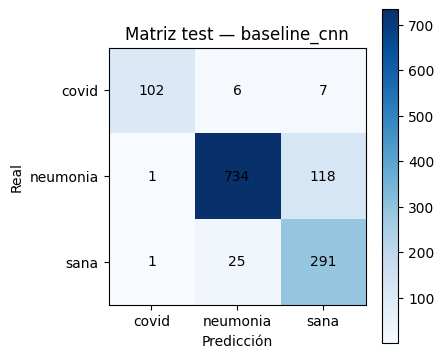

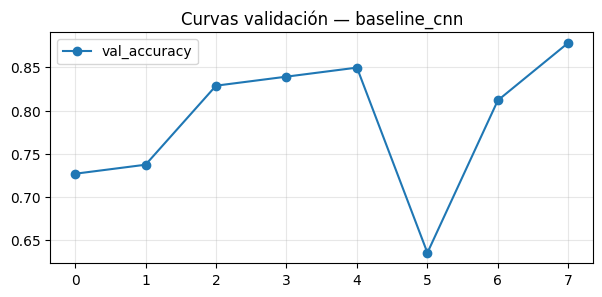

In [34]:
show_arch_stats("baseline_cnn")


### 2. ResNet50 + Transfer Learning (candidato de producción)

*Opción del enunciado:* **modelo preentrenado** + adaptación al dominio RX. Alineado con la literatura y el diseño del proyecto.



In [35]:
train_arch("resnet50")


[resnet50] Reutilizando training_report_v1.json


{'model_version': 'rx_resnet50_v1',
 'source': 'rx_resnet50_v1.h5',
 'evaluated_at': '2026-05-16T16:37:09.234399+00:00',
 'metrics_by_split': {'train': {'split': 'train',
   'n_samples': 17396,
   'accuracy': 0.9395838123706599,
   'precision_macro': 0.9430073021727052,
   'recall_macro': 0.9170076174175231,
   'f1_macro': 0.9290925146856964,
   'precision_weighted': 0.9395566373414477,
   'recall_weighted': 0.9395838123706599,
   'f1_weighted': 0.9387744876804397,
   'per_class': {'covid': {'precision': 0.9540078843626807,
     'recall': 0.928388746803069,
     'f1': 0.9410239792611795,
     'support': 1564},
    'neumonia': {'precision': 0.9388657214345287,
     'recall': 0.9754766031195841,
     'f1': 0.9568210794730132,
     'support': 11540},
    'sana': {'precision': 0.9361483007209063,
     'recall': 0.8471575023299162,
     'f1': 0.8894324853228963,
     'support': 4292}},
   'classification_report': {'covid': {'precision': 0.9540078843626807,
     'recall': 0.928388746803069,


## resnet50 — rx_resnet50_v1
TEST accuracy: 94.0% | F1 macro: 93.1% | FN neumonía→sana: 37


,split,n,acc,f1
0,train,17396,94.0%,92.9%
1,validation,765,92.8%,91.1%
2,test,1285,94.0%,93.1%


,precision,recall,f1,support
covid,97.2%,91.3%,94.2%,115.0
neumonia,96.0%,95.4%,95.7%,853.0
sana,87.8%,91.2%,89.5%,317.0


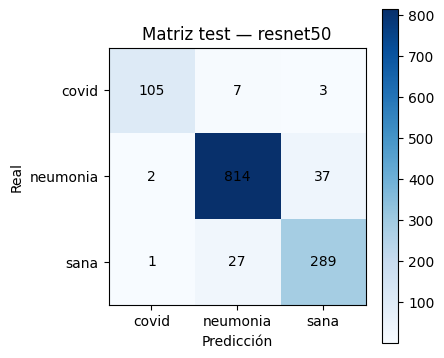

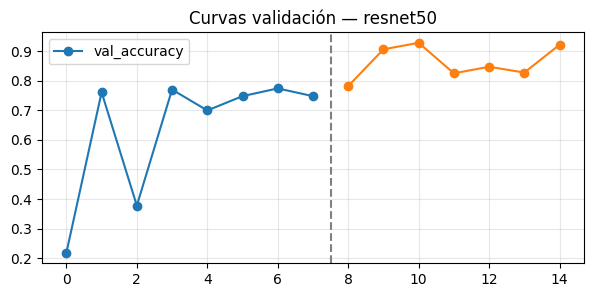

In [36]:
show_arch_stats("resnet50")


### 3. EfficientNetB0 (alternativa eficiente)

*Opción del enunciado:* CNN preentrenada con menos parámetros; se entrena para comparar eficiencia vs calidad.



In [37]:
train_arch("efficientnetb0")


[efficientnetb0] Reutilizando training_report.json


{'arch_id': 'efficientnetb0',
 'model_version': 'rx_efficientnetb0_v1',
 'features_dir': '/Users/yagoalonso/Documents/MASTER/practica-tocha/data/processed/features/v1',
 'trained_at': '2026-05-16T18:33:06.659931+00:00',
 'hyperparameters': {'batch_size': 16,
  'head_epochs': 8,
  'finetune_epochs': 6,
  'finetune_layers': 30,
  'finetune': True,
  'seed': 42,
  'class_weights': {'0': 3.7075873827791987,
   '1': 0.5024841132293472,
   '2': 1.3510406958682821},
  'total_params': 4053414},
 'history': {'accuracy': [0.31461256742477417,
   0.32737410068511963,
   0.3250747323036194,
   0.3140377104282379,
   0.32415497303009033,
   0.3140951991081238,
   0.31685444712638855,
   0.34065303206443787,
   0.3347321152687073,
   0.3529547154903412,
   0.36606115102767944,
   0.38635319471359253],
  'val_accuracy': [0.08888889104127884,
   0.6640523076057434,
   0.08888889104127884,
   0.6640523076057434,
   0.08888889104127884,
   0.6941176652908325,
   0.2849673330783844,
   0.7137255072593689

## efficientnetb0 — rx_efficientnetb0_v1
Parámetros: 4,053,414
TEST accuracy: 66.4% | F1 macro: 26.6% | FN neumonía→sana: 0


,split,n,acc,f1
0,train,17396,66.3%,26.6%
1,validation,765,66.4%,26.6%
2,test,1285,66.4%,26.6%


,precision,recall,f1,support
covid,0.0%,0.0%,0.0%,115.0
neumonia,66.4%,100.0%,79.8%,853.0
sana,0.0%,0.0%,0.0%,317.0


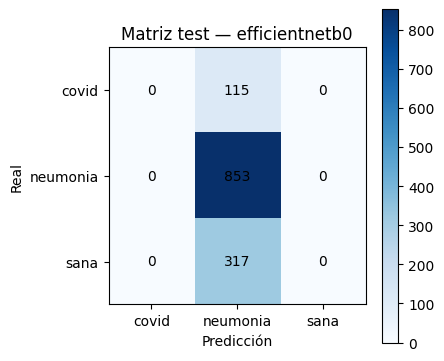

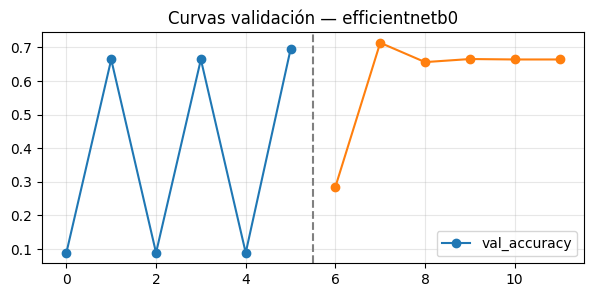

In [38]:
show_arch_stats("efficientnetb0")


### 4. DenseNet121 (alternativa literatura RX)

*Opción del enunciado:* otra CNN preentrenada citada en trabajos de clasificación de radiografías.



In [39]:
train_arch("densenet121")


[densenet121] Reutilizando training_report.json


{'arch_id': 'densenet121',
 'model_version': 'rx_densenet121_v1',
 'features_dir': '/Users/yagoalonso/Documents/MASTER/practica-tocha/data/processed/features/v1',
 'trained_at': '2026-05-16T20:21:11.690110+00:00',
 'hyperparameters': {'batch_size': 16,
  'head_epochs': 8,
  'finetune_epochs': 6,
  'finetune_layers': 40,
  'finetune': True,
  'seed': 42,
  'class_weights': {'0': 3.7075873827791987,
   '1': 0.5024841132293472,
   '2': 1.3510406958682821},
  'total_params': 7040579},
 'history': {'val_loss': [0.3066423535346985,
   0.2277529388666153,
   0.31401944160461426,
   0.24422791600227356,
   0.23641341924667358,
   0.3210635185241699,
   0.49473002552986145,
   0.3386384844779968,
   0.31145891547203064,
   0.29454052448272705,
   0.2694709300994873,
   0.2450602948665619],
  'accuracy': [0.7936307191848755,
   0.8631294369697571,
   0.8716946244239807,
   0.8730167746543884,
   0.878707766532898,
   0.8819268941879272,
   0.54115891456604,
   0.8271441459655762,
   0.8752586841

## densenet121 — rx_densenet121_v1
Parámetros: 7,040,579
TEST accuracy: 93.2% | F1 macro: 93.4% | FN neumonía→sana: 72


,split,n,acc,f1
0,train,17396,95.0%,94.7%
1,validation,765,92.4%,92.6%
2,test,1285,93.2%,93.4%


,precision,recall,f1,support
covid,96.6%,98.3%,97.4%,115.0
neumonia,98.9%,91.3%,94.9%,853.0
sana,80.5%,96.5%,87.8%,317.0


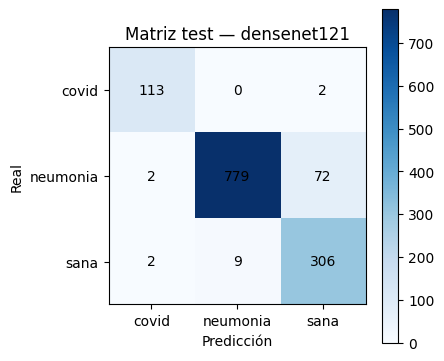

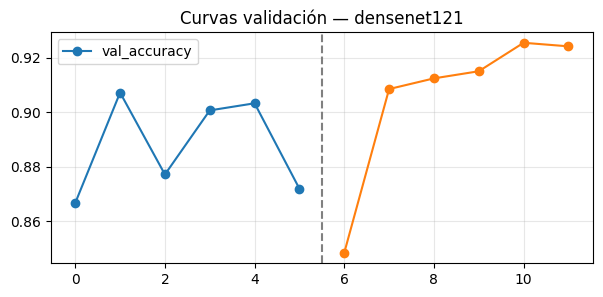

In [40]:
show_arch_stats("densenet121")


### Comparativa según el encargo

El enunciado valora **entender los errores** más que un accuracy máximo. Por eso comparamos:

- **F1 macro (test)** — rendimiento equilibrado entre clases (desbalance covid/neumonía/sana).
- **FN neumonía → sana** — error de mayor riesgo clínico (retraso de tratamiento).

El gráfico marca en verde el mejor candidato por métricas; el modelo de **producción** del proyecto sigue siendo ResNet50 por integración Docker y diseño acordado.



### Qué es F1 macro (para la memoria)

**F1 macro** es una métrica para clasificación con **varias clases** (en nuestro caso: `sana`, `neumonia`, `covid`). Resume qué tan bien el modelo acierta **en todas las clases por igual**, no solo en la más frecuente.

#### F1 de una clase

Para **una** clase (p. ej. neumonía):

- **Precisión:** de las RX que el modelo etiquetó como neumonía, ¿cuántas lo eran de verdad?
- **Recall (sensibilidad):** de las RX que **sí** eran neumonía, ¿cuántas detectó el modelo?

El **F1** combina precisión y recall en un solo número (media armónica). Si uno es muy bajo, el F1 baja aunque el otro sea alto.

#### ¿Qué significa “macro”?

Con 3 clases se calcula un F1 **por clase** (cada una como “positivo” frente al resto). Luego:

**F1 macro = media aritmética** de esos tres F1.

Cada clase pesa lo mismo en la nota final. Un modelo que va muy bien en `sana` pero fatal en `covid` no puede compensar solo con la clase mayoritaria.

#### Por qué lo usamos en la comparativa

- **Accuracy** puede engañar si una clase domina (muchas sanas → accuracy alta aunque falle en neumonía).
- **F1 macro** obliga a mirar el rendimiento **equilibrado** en las tres etiquetas.
- En este informe, **DenseNet121** ganó por F1 macro (93,4 % vs 93,1 % de ResNet50): las tres clases quedaron ligeramente mejor de media, aunque ResNet50 fue mejor en accuracy y en el error clínico prioritario (FN neumonía→sana).

| Métrica | Idea |
|---------|------|
| **Accuracy** | % de aciertos totales |
| **F1 macro** | Calidad media por clase, todas con el mismo peso |
| **FN neumonía→sana** | Error clínico concreto (criterio aparte del ranking por F1) |

> *F1 macro resume el equilibrio entre precisión y recall en las tres clases; lo usamos para comparar arquitecturas, pero la decisión operativa también considera errores clínicos críticos.*

Ranking F1 (test): densenet121 > resnet50 > baseline_cnn > efficientnetb0
Ganador por métricas: densenet121
Modelo producción (proyecto): resnet50


,accuracy_test,f1_macro_test,fn_neumonia→sana,params
arquitectura,,,,
baseline_cnn,87.7%,87.8%,118,93635.0
resnet50,94.0%,93.1%,37,NaN
efficientnetb0,66.4%,26.6%,0,4053414.0
densenet121,93.2%,93.4%,72,7040579.0


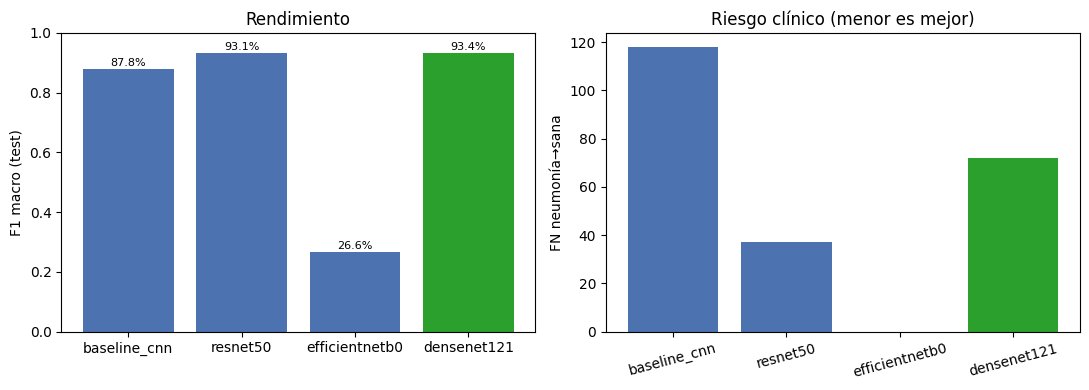

In [41]:
entries = {a: report_to_comparison_entry(reports[a]) for a in ARCH_ORDER}
comparison_path = write_architecture_comparison(entries)
comparison = json.loads(comparison_path.read_text(encoding="utf-8"))

print("Ranking F1 (test):", " > ".join(comparison["ranking_test_f1_macro"]))
print("Ganador por métricas:", comparison["recommended"])
print("Modelo producción (proyecto):", comparison["production_model"])

cmp_rows = []
for arch in ARCH_ORDER:
    mod = comparison["models"][arch]
    t = mod["test"]
    cmp_rows.append(
        {
            "arquitectura": arch,
            "accuracy_test": t["accuracy"],
            "f1_macro_test": t["f1_macro"],
            "fn_neumonia→sana": mod["fn_neumonia_sana"],
            "params": mod.get("total_params"),
        }
    )
cmp_df = pd.DataFrame(cmp_rows).set_index("arquitectura")
show = cmp_df.copy()
show["accuracy_test"] = show["accuracy_test"].map(lambda x: f"{x:.1%}")
show["f1_macro_test"] = show["f1_macro_test"].map(lambda x: f"{x:.1%}")
display(show)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
f1_vals = [comparison["models"][a]["test"]["f1_macro"] for a in ARCH_ORDER]
fn_vals = [comparison["models"][a]["fn_neumonia_sana"] for a in ARCH_ORDER]
colors = ["#2ca02c" if a == comparison["recommended"] else "#4c72b0" for a in ARCH_ORDER]
axes[0].bar(ARCH_ORDER, f1_vals, color=colors)
axes[0].set_ylabel("F1 macro (test)")
axes[0].set_title("Rendimiento")
axes[0].set_ylim(0, 1)
for i, v in enumerate(f1_vals):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=8)
axes[1].bar(ARCH_ORDER, fn_vals, color=colors)
axes[1].set_ylabel("FN neumonía→sana")
axes[1].set_title("Riesgo clínico (menor es mejor)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Conclusión honesta para la memoria

Habéis **investigado 4 arquitecturas** (requisito del enunciado: CNN, modelos preentrenados, etc.). Resultados en test (1 285 RX):

| Modelo | Accuracy | F1 macro | FN neumonía→sana |
|--------|----------|----------|-----------------|
| **densenet121** | 93,2 % | **93,4 %** | 72 |
| **resnet50** | **94,0 %** | 93,1 % | **37** |
| baseline_cnn | 87,7 % | 87,8 % | 118 |
| efficientnetb0 | 66,4 % | 26,6 % | — (colapso; no usable) |

El script de comparación ordena por **F1 macro** → ganador numérico: **DenseNet121**. En métricas globales **DenseNet y ResNet están muy parejos** (diferencia de F1 menor de 0,3 puntos porcentuales).

**Para producción en laSalle seguimos con ResNet50** porque:

- **Menor FN crítico** (37 vs 72 neumonías clasificadas como sanas) — el encargo valora el impacto clínico más que el accuracy perfecto.
- **Mayor accuracy** en test (94,0 % vs 93,2 %).
- **Stack ya integrado** en Docker, checkpoints e informes del proyecto.

> *DenseNet121 obtuvo el F1 macro ligeramente superior en la comparativa; sin embargo, ResNet50 reduce los falsos negativos neumonía→sana y es el modelo operativo del sistema.*

| Criterio del enunciado | Cómo lo cumplís |
|------------------------|-----------------|
| Investigar arquitecturas | 4 candidatos entrenados con el mismo protocolo |
| Modelos preentrenados | ResNet50, EfficientNetB0, DenseNet121 (ImageNet) |
| Matriz de confusión y reflexión clínica | Por modelo en este notebook + `evaluacion-clinica-v1.md` |
| No depender del accuracy perfecto | Análisis de FN/FP y limitaciones explícitas |

**EfficientNetB0:** entrenamiento inestable (F1 26,6 %); no se considera para despliegue — documentar como limitación del experimento.

**Entregables:** `architecture_comparison.json`, `resultados-entrenamiento-v1.md`, `evaluacion-clinica-v1.md`.

